### Load Data / Packages

In [1]:
# 2. Import core libraries
import os
import numpy as np
import pandas as pd
import arviz as az

In [2]:
from google.cloud import bigquery
#Authenticate
from google.colab import auth
auth.authenticate_user()

# Set your GCP project (REPLACE)
project_id = "north-spore"
location = 'US'

client = bigquery.Client(project=project_id, location=location)

##### Platform Breakdown (Exclude Amazon - no region)

In [ ]:
# @title
# query = """
# SELECT
#     DATE_TRUNC(Date, WEEK(MONDAY)) AS date,
#     State as geo,
#     SUM(CASE WHEN Platform = 'Google'  THEN Cost ELSE 0 END) AS Google_Cost,
#     SUM(CASE WHEN Platform = 'Facebook' THEN Cost ELSE 0 END) AS Facebook_Cost,
#     SUM(CASE WHEN Platform = 'DVD'     THEN Cost ELSE 0 END) AS DVD_Cost,
#     -- SUM(CASE WHEN Platform = 'Amazon'     THEN Cost ELSE 0 END) AS Amazon_Cost,
#     SUM(CASE WHEN Platform = 'Google'       THEN Impressions ELSE 0 END) AS Google_Impressions,
#     SUM(CASE WHEN Platform = 'Facebook'   THEN Impressions ELSE 0 END) AS Facebook_Impressions,
#     SUM(CASE WHEN Platform = 'DVD'         THEN Impressions ELSE 0 END) AS DVD_Impressions,
#     -- SUM(CASE WHEN Platform = 'Amazon'     THEN Impressions ELSE 0 END) AS Amazon_Impressions,
#     SUM(Shopify_Purchases) AS Purchases,
#     SUM(Shopify_Revenue) AS Revenue,
# FROM `north_spore_segments.northspore_mmm_data`
# WHERE Date >= "2023-08-01" AND Date < CURRENT_DATE()
# AND State != "Other"
# GROUP BY date, geo
# ORDER BY date DESC
# """

##### Type Breakdown

In [3]:
query = """
WITH base AS (
  SELECT * EXCEPT(Type),
    CASE
      --WHEN Platform = "Amazon" THEN "Amazon"
      WHEN Platform = "DVD" THEN "DVD"
      ELSE Type
    END AS Type
  FROM `north-spore.north_spore_segments.full_segments_region`
)

SELECT
  DATE_TRUNC(Date, WEEK(MONDAY)) AS date,
  State AS geo,

  -- COST
  SUM(CASE WHEN Type = 'DVD'            THEN Cost ELSE 0 END) AS DVD_Cost,
  SUM(CASE WHEN Type = 'Competitors'    THEN Cost ELSE 0 END) AS Competitors_Cost,
  SUM(CASE WHEN Type = 'Retargeting'    THEN Cost ELSE 0 END) AS Retargeting_Cost,
  SUM(CASE WHEN Type = 'Brand Shopping' THEN Cost ELSE 0 END) AS Brand_Shopping_Cost,
  SUM(CASE WHEN Type = 'Shopping'       THEN Cost ELSE 0 END) AS Shopping_Cost,
  SUM(CASE WHEN Type = 'Prospecting'    THEN Cost ELSE 0 END) AS Prospecting_Cost,
  SUM(CASE WHEN Type = 'Remarketing'    THEN Cost ELSE 0 END) AS Remarketing_Cost,
  SUM(CASE WHEN Type = 'Brand'          THEN Cost ELSE 0 END) AS Brand_Cost,
  --SUM(CASE WHEN Type = 'Amazon'         THEN Cost ELSE 0 END) AS Amazon_Cost,
  SUM(CASE WHEN Type = 'Non-Brand'      THEN Cost ELSE 0 END) AS Non_Brand_Cost,

  -- IMPRESSIONS
  SUM(CASE WHEN Type = 'DVD'            THEN Impressions ELSE 0 END) AS DVD_Impressions,
  SUM(CASE WHEN Type = 'Competitors'    THEN Impressions ELSE 0 END) AS Competitors_Impressions,
  SUM(CASE WHEN Type = 'Retargeting'    THEN Impressions ELSE 0 END) AS Retargeting_Impressions,
  SUM(CASE WHEN Type = 'Brand Shopping' THEN Impressions ELSE 0 END) AS Brand_Shopping_Impressions,
  SUM(CASE WHEN Type = 'Shopping'       THEN Impressions ELSE 0 END) AS Shopping_Impressions,
  SUM(CASE WHEN Type = 'Prospecting'    THEN Impressions ELSE 0 END) AS Prospecting_Impressions,
  SUM(CASE WHEN Type = 'Remarketing'    THEN Impressions ELSE 0 END) AS Remarketing_Impressions,
  SUM(CASE WHEN Type = 'Brand'          THEN Impressions ELSE 0 END) AS Brand_Impressions,
  --SUM(CASE WHEN Type = 'Amazon'         THEN Impressions ELSE 0 END) AS Amazon_Impressions,
  SUM(CASE WHEN Type = 'Non-Brand'      THEN Impressions ELSE 0 END) AS Non_Brand_Impressions,

  -- TOTALS
  SUM(Shopify_Purchases) AS Purchases,
  SUM(Shopify_Revenue) AS Revenue

FROM base
WHERE Date >= '2024-01-01'
  AND Date < CURRENT_DATE()
  AND State != 'Other'

GROUP BY date, geo
ORDER BY date DESC;
"""

In [4]:
pmax_query = """
SELECT
  DATE_TRUNC(Date, WEEK(MONDAY)) AS date,
  SUM(CASE WHEN Type = 'Performance Max' THEN Cost ELSE 0 END) AS Pmax_Cost,
  SUM(CASE WHEN Type = 'Performance Max' THEN Impressions ELSE 0 END) AS Pmax_Impressions,
  FROM `north-spore.north_spore_segments.full_segments`
  WHERE Date >= '2024-01-01'
  GROUP BY date
  ORDER BY date ASC;
"""

In [5]:
raw_data = client.query(query).to_dataframe()

In [6]:
pmax_data = client.query(pmax_query).to_dataframe()

### Clean State

In [7]:
viable_states = ['MT', 'OH', 'NE', 'AZ', 'CO', 'MI', 'MO', 'WI', 'DE', 'MA',
 'WY', 'MD', 'MS', 'CT', 'GA', 'SD', 'ID', 'KS', 'WV', 'KY',
 'TN', 'FL', 'IA', 'WA', 'CA', 'TX', 'DC', 'HI', 'RI', 'NJ',
 'VT', 'NH', 'NC', 'ME', 'SC', 'UT', 'PA', 'NY', 'IL', 'NM',
 'AK', 'AR', 'MN', 'VA', 'LA', 'OR', 'AL', 'OK', 'NV', 'IN',
 'ND']

In [8]:
raw_data = raw_data[raw_data['geo'].isin(viable_states)]
raw_data.geo.unique()

array(['WI', 'UT', 'DC', 'NC', 'IA', 'WA', 'AZ', 'SC', 'CA', 'NE', 'NY',
       'FL', 'MN', 'VT', 'TN', 'VA', 'MA', 'WV', 'IL', 'ND', 'OK', 'PA',
       'CT', 'NM', 'RI', 'CO', 'MS', 'TX', 'NV', 'NH', 'MD', 'OH', 'OR',
       'MI', 'IN', 'AR', 'ME', 'MO', 'WY', 'LA', 'GA', 'HI', 'AL', 'MT',
       'NJ', 'KY', 'SD', 'AK', 'KS', 'DE', 'ID'], dtype=object)

### Add in Context Variables

Black Friday

In [9]:
bf_dates = ["2025-11-17", "2025-11-24", "2025-12-01", "2024-11-18", "2024-11-25", "2024-12-02"]

raw_data["bf_date"] = raw_data["date"].isin(bf_dates).astype(int)

### Ensure we have rows for all dates/geos

In [10]:
# 1. Ensure 'date' is a proper datetime object
raw_data['date'] = pd.to_datetime(raw_data['date'])

# 2. Get the unique list of all dates and all geos
all_dates = raw_data['date'].unique()
all_geos = raw_data['geo'].unique()

# 3. Create a 'Perfect Index' of all possible combinations
perfect_index = pd.MultiIndex.from_product(
    [all_dates, all_geos],
    names=['date', 'geo']
)
perfect_df = pd.DataFrame(index=perfect_index).reset_index()

# 4. Merge your data into the perfect structure
# Use 'left' join so we keep every date/geo combo, filling missing with 0
raw_data = pd.merge(perfect_df, raw_data, on=['date', 'geo'], how='left').fillna(0)

# 5. Sort to ensure alignment (VERY important for Meridian)
raw_data = raw_data.sort_values(['geo', 'date']).reset_index(drop=True)

print(f"Data Re-aligned! Total rows should be {len(all_dates) * len(all_geos)}.")
print(f"Current rows: {len(raw_data)}")

Data Re-aligned! Total rows should be 6273.
Current rows: 6273


### Assign populations to each geo

In [11]:
# @title
state_population_map = {
    'PA': 13210000,
    'NH': 1400000,
    'GA': 11400000,
    'ID': 2010000,
    'WI': 5960000,
    'MO': 6190000,
    'KY': 4540000,
    'MI': 10300000,
    'NE': 1980000,
    'SC': 5660000,
    'CO': 6070000,
    'CA': 39900000,
    'WA': 8160000,
    'IL': 12800000,
    'IA': 3210000,
    'NJ': 9740000,
    'AR': 3080000,
    'MA': 7280000,
    'MN': 5790000,
    'OR': 4300000,
    'KS': 2950000,
    'AL': 5100000,
    'NV': 3220000,
    'IN': 7010000,
    'MS': 2960000,
    'HI': 1440000,
    'WY': 590000,
    'DE': 1080000,
    'VT': 650000,
    'ME': 1390000,
    'NC': 11400000,
    'AZ': 7800000,
    'OH': 12000000,
    'UT': 3500000,
    'MT': 1140000,
    'RI': 1110000,
    'DC': 680000,
    'ND': 810000,
    'MD': 6360000,
    'CT': 3620000,
    'OK': 4090000,
    'SD': 920000,
    'WV': 1770000,
    'LA': 4590000,
    'VA': 8960000,
    'AK': 750000,
    'TN': 7390000,
    'FL': 24300000,
    'NM': 2120000,
    'TX': 32400000,
    'NY': 20100000
}

In [12]:
# Assign to your dataframe
# This looks at your 'geo' column and creates a 'population' column based on the map
raw_data['population'] = raw_data['geo'].map(state_population_map)

# Double check for any missing values (typos in geo names)
missing_count = raw_data['population'].isna().sum()
if missing_count > 0:
    print(f"Warning: {missing_count} rows have no population mapping. Check your geo names!")
else:
    print("Population mapping successful!")

Population mapping successful!


### Merging Pmax and Raw Data

In [13]:
raw_data["date"] = pd.to_datetime(raw_data["date"])
pmax_data["date"] = pd.to_datetime(pmax_data["date"])

# 1) Build population weights per (date, geo)
pop = (
    raw_data[["date", "geo", "population"]]
    .dropna(subset=["population"])
    .drop_duplicates(subset=["date", "geo"])
    .copy()
)
pop["total_pop_date"] = pop.groupby("date")["population"].transform("sum")
pop["pop_weight"] = np.where(pop["total_pop_date"] > 0,
                             pop["population"] / pop["total_pop_date"],
                             0)

# 2) Expand amazon totals across geos using weights
pmx_cols = ["Pmax_Cost", "Pmax_Impressions"]
expanded = pop.merge(pmax_data[["date"] + pmx_cols], on="date", how="left")

for c in pmx_cols:
    expanded[c] = expanded[c].fillna(0) * expanded["pop_weight"]

# expanded = expanded.rename(columns={
#     "pmax_Cost": "pmax_cost",
#     "pmax_Impressions": "pmax_impressions",
#     "pmax_Conversions": "pmax_conversions_allocated",
#     "pmax_Revenue": "pmax_revenue_allocated",
# })

# 3) Merge back into raw_data
out = raw_data.merge(
    expanded[["date", "geo", "Pmax_Cost", "Pmax_Impressions"]],
    on=["date", "geo"],
    how="left",
)

# 4) Fill missing allocations + roll into Purchases/Revenue
for c in ["Pmax_Cost", "Pmax_Impressions"]:
    out[c] = out[c].fillna(0)

In [14]:
out

,date,geo,DVD_Cost,Competitors_Cost,Retargeting_Cost,Brand_Shopping_Cost,Shopping_Cost,Prospecting_Cost,Remarketing_Cost,Brand_Cost,...,Prospecting_Impressions,Remarketing_Impressions,Brand_Impressions,Non_Brand_Impressions,Purchases,Revenue,bf_date,population,Pmax_Cost,Pmax_Impressions
0,2024-01-01,AK,7.022993,0.0,17.694355,0.00,14.75,65.032256,0.000000,5.400000,...,14540,0,30,2559,12.0,1358.99,0,750000,0.000000,0.0
1,2024-01-08,AK,3.164727,0.0,16.395904,0.00,44.81,60.292926,0.000000,5.510000,...,11620,0,53,3125,13.0,1745.00,0,750000,0.000000,0.0
2,2024-01-15,AK,9.586830,0.0,16.064609,0.00,23.62,68.541314,0.000000,16.710000,...,10939,0,40,2205,19.0,1995.00,0,750000,0.000000,0.0
3,2024-01-22,AK,10.641802,0.0,19.754004,0.00,21.61,74.123413,0.000000,13.370000,...,12003,0,60,2671,21.0,2437.00,0,750000,0.000000,0.0
4,2024-01-29,AK,9.629326,0.0,20.485583,0.00,65.43,70.342600,0.000000,40.190000,...,9525,0,43,1061,18.0,1920.00,0,750000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6268,2026-04-06,WY,2.007097,0.0,2.490032,2.32,34.06,48.755216,2.120087,3.294402,...,4840,250,36,157,7.0,371.88,0,590000,7.959174,1187.129295
6269,2026-04-13,WY,5.055754,0.0,2.840230,1.65,35.58,71.064208,2.990076,3.441891,...,5793,215,46,245,12.0,1355.20,0,590000,8.369750,1257.159105
6270,2026-04-20,WY,5.103239,0.0,1.929980,9.95,33.48,54.127366,1.879959,7.229857,...,4833,274,40,243,11.0,1233.75,0,590000,11.198540,1367.346109
6271,2026-04-27,WY,2.082808,0.0,2.330109,0.73,17.13,32.799533,0.889935,3.162109,...,2583,108,29,223,6.0,811.77,0,590000,8.903954,997.933774


### Bring in Organic Data

24-25 Organic Data

In [15]:
ig_data_hist = pd.read_csv('NS_IG_data.csv')
fb_data_hist = pd.read_csv('NS_FB_data.csv')
yt_data_hist = pd.read_csv('NS_YT_data.csv')

In [17]:
ig_data = pd.read_csv('NS_IG_data_Apr26.csv')
fb_data = pd.read_csv('NS_FB_data_Apr26.csv')
yt_data = pd.read_csv('NS_YT_data_Apr26.csv')

In [18]:
ig_data_hist['Date'] = pd.to_datetime(ig_data_hist['Date'])
ig_data_hist = ig_data_hist[ig_data_hist['Date'] < '2026-01-01']

In [19]:
yt_data_hist['Date'] = pd.to_datetime(yt_data_hist['Date'])
yt_data_hist = yt_data_hist[yt_data_hist['Date'] < '2026-01-01']

In [20]:
fb_data_hist['Date'] = pd.to_datetime(fb_data_hist['Date'])
fb_data_hist = fb_data_hist[fb_data_hist['Date'] < '2026-01-01']

In [21]:
fb_data = pd.concat([fb_data, fb_data_hist])
ig_data = pd.concat([ig_data, ig_data_hist])
yt_data = pd.concat([yt_data, yt_data_hist])

In [22]:
ig_data.drop(columns=['Data Source description', 'Comments', 'Likes'], inplace=True)
ig_data['Data Source'] = "Instagram"

In [23]:
fb_data.drop(columns=['Data Source description'], inplace=True)
fb_data.rename(columns={'Organic Impressions':'Views'}, inplace=True)
fb_data['Data Source'] = "Facebook"

In [24]:
yt_data.drop(columns=['Data Source description', 'Comments', 'Likes'], inplace=True)
yt_data['Data Source'] = "YouTube"

Merge Data

In [25]:
full_organic = pd.concat([ig_data, fb_data, yt_data])

In [26]:
full_organic.rename(columns={'Date':'date'}, inplace=True)

In [27]:
full_organic.columns

Index(['date', 'Views', 'Data Source'], dtype='object')

In [28]:
full_organic["date"] = pd.to_datetime(full_organic["date"])

# 2) Expand amazon totals across geos using weights
org_cols = ["Views"]
expanded = pop.merge(full_organic[["date", 'Data Source'] + org_cols], on="date", how="left")

for c in org_cols:
    expanded[c] = expanded[c].fillna(0) * expanded["pop_weight"]

In [29]:
expanded['Data Source'].value_counts()

,count
Data Source,
YouTube,5916
Facebook,5661
Instagram,3621


In [30]:
expanded_organic = expanded.pivot_table(index=['date', 'geo'],
                                       columns='Data Source',
                                       values='Views',
                                       fill_value=0)

# Flatten the multi-index columns and rename for clarity
expanded_organic.columns = [f'{col}_Views' for col in expanded_organic.columns]
expanded_organic = expanded_organic.reset_index()

In [31]:
# Group by week (Monday start) and geo, summing all view columns
organic_final = (
    expanded_organic.groupby([pd.Grouper(key='date', freq='W-MON', label='left', closed='left'), 'geo'])
    [['Facebook_Views', 'Instagram_Views', 'YouTube_Views']]
    .sum()
    .reset_index()
)

In [32]:
organic_final.head()

,date,geo,Facebook_Views,Instagram_Views,YouTube_Views
0,2024-02-12,AK,0.0,0.0,38.562489
1,2024-02-12,AL,0.0,0.0,262.224926
2,2024-02-12,AR,0.0,0.0,158.363289
3,2024-02-12,AZ,0.0,0.0,401.049887
4,2024-02-12,CA,0.0,0.0,2051.524422


In [33]:
raw_data = pd.merge(out, organic_final, on=['date', 'geo'], how='left')

In [34]:
raw_data.fillna(0, inplace=True)

In [35]:
raw_data.head()

,date,geo,DVD_Cost,Competitors_Cost,Retargeting_Cost,Brand_Shopping_Cost,Shopping_Cost,Prospecting_Cost,Remarketing_Cost,Brand_Cost,...,Non_Brand_Impressions,Purchases,Revenue,bf_date,population,Pmax_Cost,Pmax_Impressions,Facebook_Views,Instagram_Views,YouTube_Views
0,2024-01-01,AK,7.022993,0.0,17.694355,0.0,14.75,65.032256,0.0,5.40,...,2559,12.0,1358.99,0,750000,0.0,0.0,0.0,0.0,0.0
1,2024-01-08,AK,3.164727,0.0,16.395904,0.0,44.81,60.292926,0.0,5.51,...,3125,13.0,1745.00,0,750000,0.0,0.0,0.0,0.0,0.0
2,2024-01-15,AK,9.586830,0.0,16.064609,0.0,23.62,68.541314,0.0,16.71,...,2205,19.0,1995.00,0,750000,0.0,0.0,0.0,0.0,0.0
3,2024-01-22,AK,10.641802,0.0,19.754004,0.0,21.61,74.123413,0.0,13.37,...,2671,21.0,2437.00,0,750000,0.0,0.0,0.0,0.0,0.0
4,2024-01-29,AK,9.629326,0.0,20.485583,0.0,65.43,70.342600,0.0,40.19,...,1061,18.0,1920.00,0,750000,0.0,0.0,0.0,0.0,0.0


### 2) Data quality checks and EDA


####Validate time coverage continuity across geos and variables

In [ ]:
# Ensure datetime
raw_data['date'] = pd.to_datetime(raw_data['date'])

print("Global Date Range:")
print("Min Date:", raw_data['date'].min())
print("Max Date:", raw_data['date'].max())
print("Total Unique Weeks:", raw_data['date'].nunique())

Global Date Range:
Min Date: 2024-01-01 00:00:00
Max Date: 2026-03-30 00:00:00
Total Unique Weeks: 118


In [ ]:
geo_time_check = raw_data.groupby('geo').agg(
    min_date=('date', 'min'),
    max_date=('date', 'max'),
    n_periods=('date', 'nunique')
).reset_index()

In [ ]:
#geo_time_check

In [ ]:
expected_periods = raw_data['date'].nunique()

geo_time_check['period_match'] = geo_time_check['n_periods'] == expected_periods

#geo_time_check

In [ ]:
n_geos = raw_data['geo'].nunique()
n_dates = raw_data['date'].nunique()
expected_rows = n_geos * n_dates

print("Expected rows:", expected_rows)
print("Actual rows:", len(raw_data))

Expected rows: 6018
Actual rows: 6018


In [ ]:
raw_data.columns

Index(['date', 'geo', 'DVD_Cost', 'Competitors_Cost', 'Retargeting_Cost',
       'Brand_Shopping_Cost', 'Shopping_Cost', 'Prospecting_Cost',
       'Remarketing_Cost', 'Brand_Cost', 'Non_Brand_Cost', 'DVD_Impressions',
       'Competitors_Impressions', 'Retargeting_Impressions',
       'Brand_Shopping_Impressions', 'Shopping_Impressions',
       'Prospecting_Impressions', 'Remarketing_Impressions',
       'Brand_Impressions', 'Non_Brand_Impressions', 'Purchases', 'Revenue',
       'bf_date', 'population', 'Pmax_Cost', 'Pmax_Impressions',
       'Facebook_Views', 'Instagram_Views', 'YouTube_Views'],
      dtype='object')

In [ ]:
columns_to_check = [
    'Purchases', 'Revenue',
    'Brand_Cost', 'Non_Brand_Cost', 'DVD_Cost',
    'Retargeting_Cost', 'Prospecting_Cost', 'Pmax_Cost',
    'Brand_Impressions', 'Non_Brand_Impressions',
    'DVD_Impressions', 'Retargeting_Impressions',
    'Prospecting_Impressions', "Pmax_Impressions"
]

null_summary = raw_data[columns_to_check].isnull().sum()

null_summary


,0
Purchases,0
Revenue,0
Brand_Cost,0
Non_Brand_Cost,0
DVD_Cost,0
Retargeting_Cost,0
Prospecting_Cost,0
Pmax_Cost,0
Brand_Impressions,0
Non_Brand_Impressions,0


In [ ]:
date_diffs = raw_data[['date']].drop_duplicates().sort_values('date')
date_diffs['diff'] = date_diffs['date'].diff()

print(date_diffs['diff'].value_counts())

diff
7 days    117
Name: count, dtype: int64


#### Validate spend and media units distributions per channel (zeros, spikes, outliers)

In [ ]:
channels = [
    'Brand', 'Non_Brand', 'DVD', 'Competitors', 'Remarketing',
     'Brand_Shopping', 'Shopping',
    'Retargeting', 'Prospecting', 'Pmax'
]

spend_cols = [f"{c}_Cost" for c in channels]
imp_cols   = [f"{c}_Impressions" for c in channels]

In [ ]:
zero_summary = []

for col in spend_cols:
    pct_zero = (raw_data[col] == 0).mean()
    zero_summary.append({
        "channel": col,
        "pct_zero_spend": round(pct_zero * 100, 2)
    })

pd.DataFrame(zero_summary).sort_values("pct_zero_spend", ascending=False)

,channel,pct_zero_spend
3,Competitors_Cost,92.99
5,Brand_Shopping_Cost,50.76
4,Remarketing_Cost,37.35
9,Pmax_Cost,25.42
2,DVD_Cost,24.66
8,Prospecting_Cost,1.10
6,Shopping_Cost,0.45
0,Brand_Cost,0.00
1,Non_Brand_Cost,0.00
7,Retargeting_Cost,0.00


In [ ]:
dist_summary = raw_data[spend_cols].describe().T
dist_summary['skew'] = raw_data[spend_cols].skew()
dist_summary

,count,mean,std,min,25%,50%,75%,max,skew
Brand_Cost,6018.0,48.837988,50.604892,0.030000,14.220730,31.984831,68.014808,477.831637,2.409310
Non_Brand_Cost,6018.0,146.651121,150.451610,0.962330,44.784115,93.507375,199.105282,1683.220000,2.378938
DVD_Cost,6018.0,16.393858,25.758668,0.000000,0.074278,6.772493,20.129353,270.290558,3.043354
Competitors_Cost,6018.0,0.311010,1.779543,0.000000,0.000000,0.000000,0.000000,43.320000,10.311886
Remarketing_Cost,6018.0,31.442815,54.849750,0.000000,0.000000,9.519706,39.414616,613.343456,3.512191
Brand_Shopping_Cost,6018.0,14.511801,24.545522,0.000000,0.000000,0.000000,21.017500,264.430000,2.523824
Shopping_Cost,6018.0,220.038142,231.800588,0.000000,61.005000,140.295000,300.297789,2372.680000,2.112312
Retargeting_Cost,6018.0,38.836458,49.715982,0.060001,7.586349,20.026136,45.683557,406.462208,2.336358
Prospecting_Cost,6018.0,234.697310,220.134584,0.000000,80.707356,161.184355,333.809732,2851.930626,2.252652
Pmax_Cost,6018.0,68.196642,205.847121,0.000000,0.000000,7.622828,49.093040,5071.259199,8.912822


In [ ]:
outlier_summary = []

for col in spend_cols:
    q1 = raw_data[col].quantile(0.25)
    q3 = raw_data[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 3 * iqr

    spikes = (raw_data[col] > upper_bound).sum()

    outlier_summary.append({
        "channel": col,
        "num_extreme_spikes": spikes,
        "upper_bound_threshold": round(upper_bound, 2)
    })

pd.DataFrame(outlier_summary)

,channel,num_extreme_spikes,upper_bound_threshold
0,Brand_Cost,72,229.40
1,Non_Brand_Cost,75,662.07
2,DVD_Cost,203,80.29
3,Competitors_Cost,422,0.00
4,Remarketing_Cost,207,157.66
5,Brand_Shopping_Cost,166,84.07
6,Shopping_Cost,76,1018.18
7,Retargeting_Cost,248,159.98
8,Prospecting_Cost,42,1093.12
9,Pmax_Cost,510,196.37


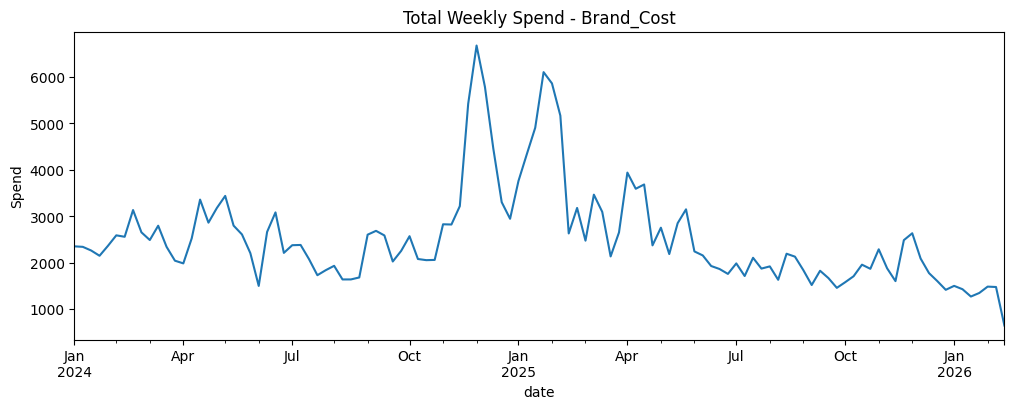

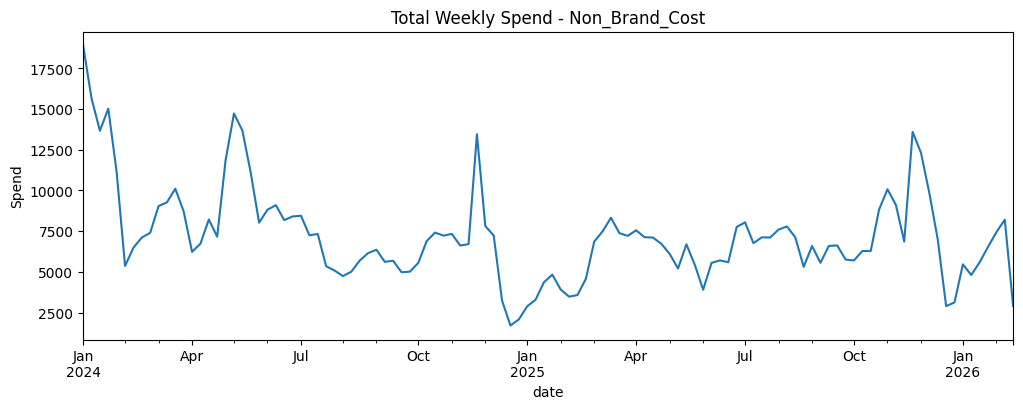

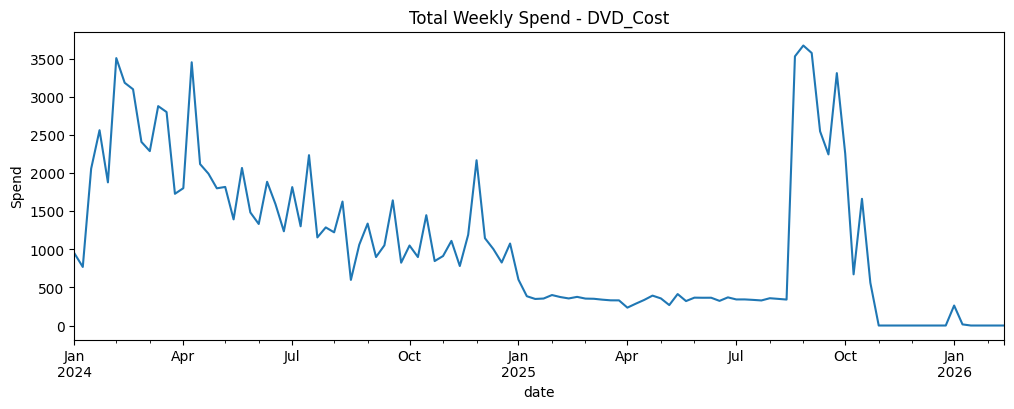

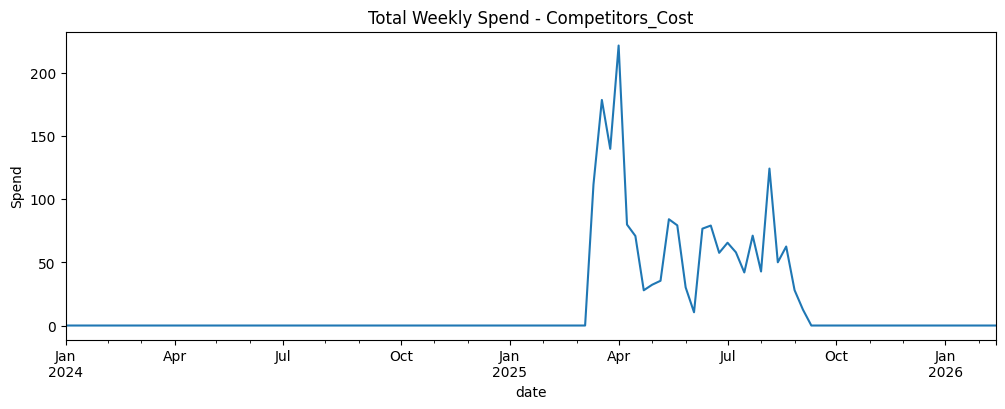

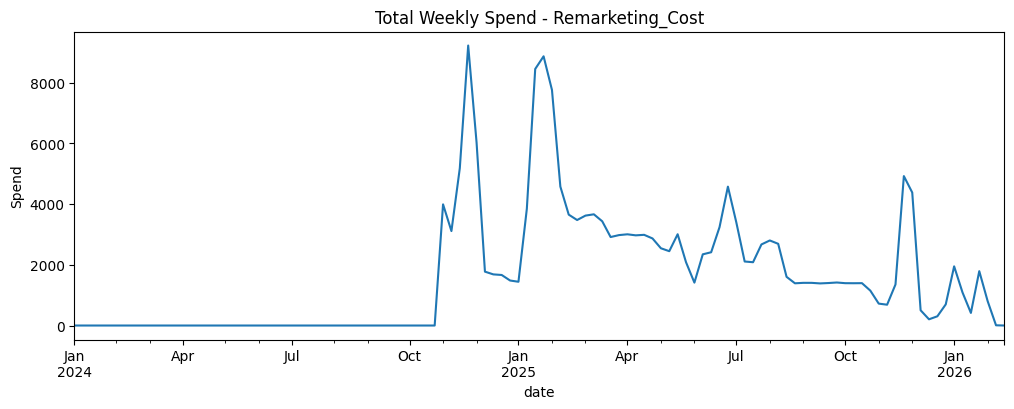

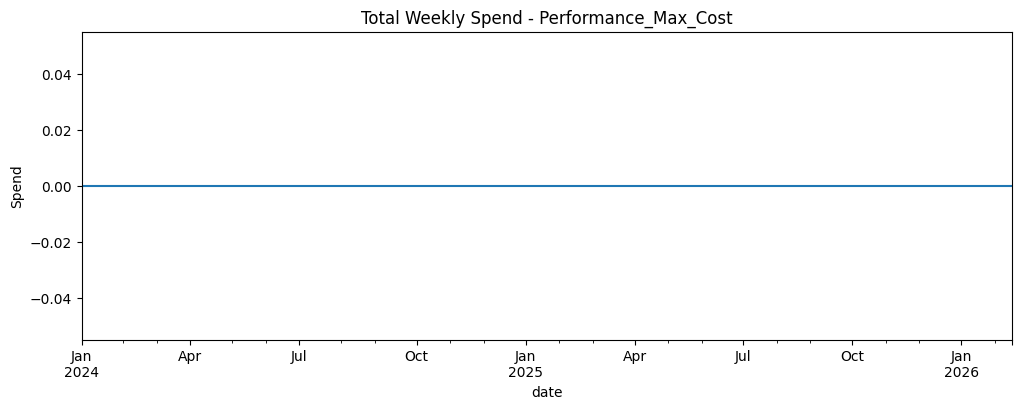

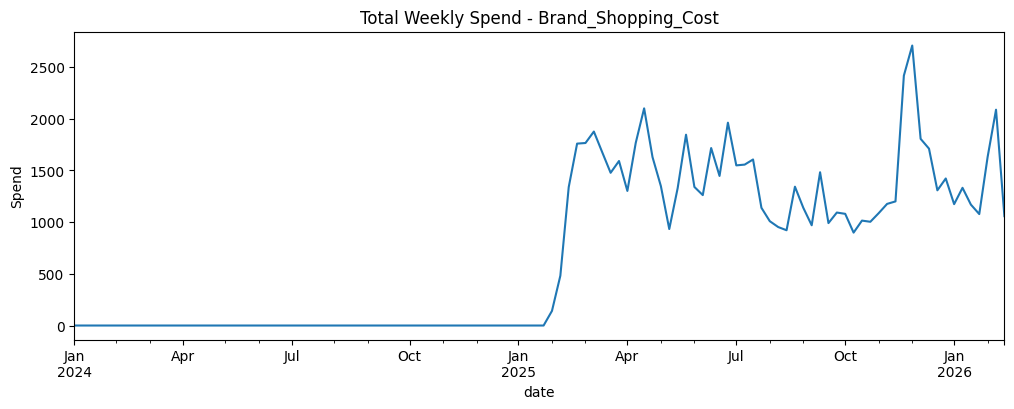

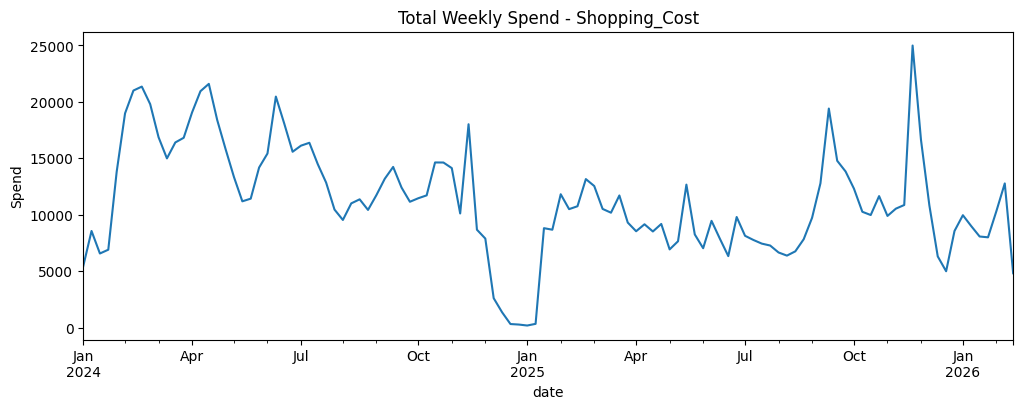

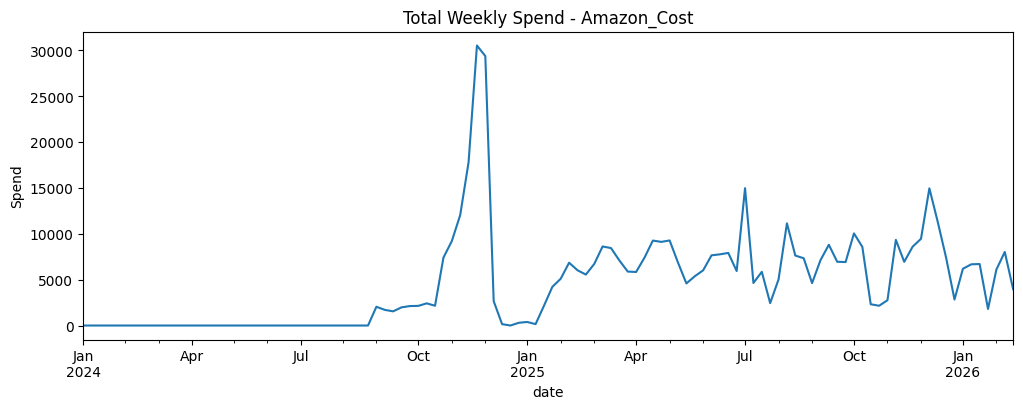

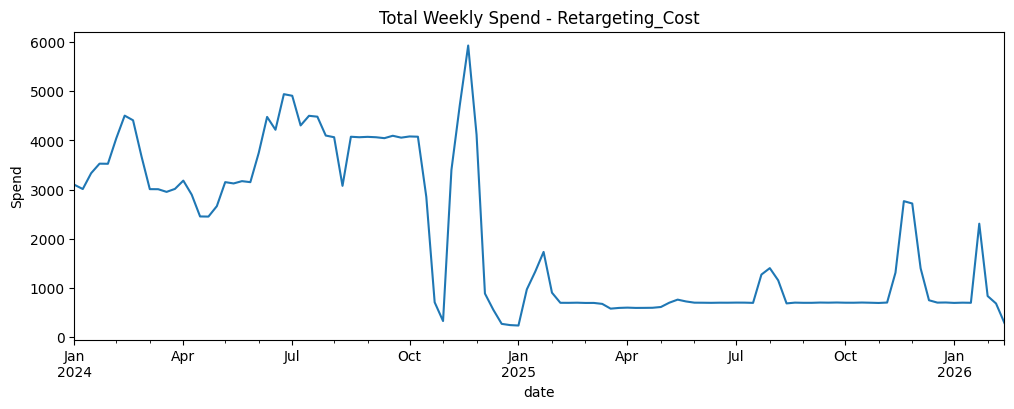

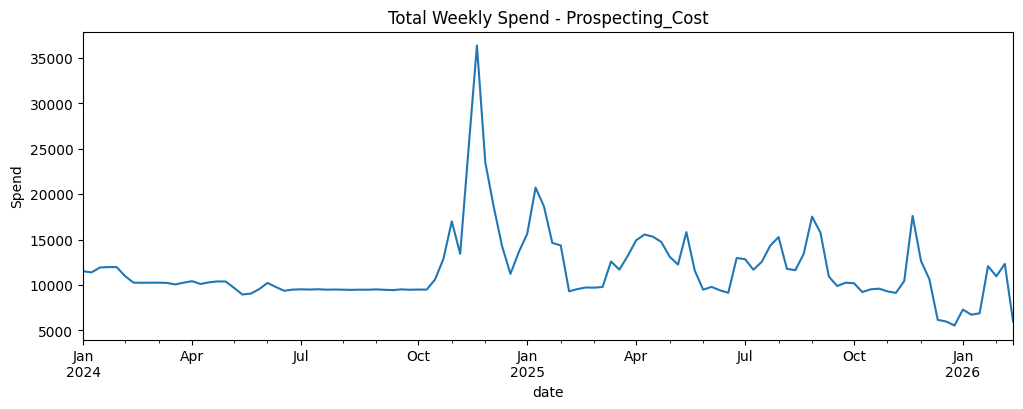

In [ ]:
import matplotlib.pyplot as plt

for col in spend_cols:
    plt.figure(figsize=(12,4))
    raw_data.groupby('date')[col].sum().plot()
    plt.title(f"Total Weekly Spend - {col}")
    plt.ylabel("Spend")
    plt.show()

In [ ]:
geo_spend_check = (
    raw_data
    .groupby('geo')[spend_cols]
    .agg(['mean','std','max'])
)

geo_spend_check

Brand_Cost                        Non_Brand_Cost              \
           mean        std         max           mean         std   
geo                                                                 
AK    12.029711   8.186352   40.785828      47.661346   22.862844   
AL    26.620880  15.917329  101.432490      75.337425   37.632094   
AR    21.783662  12.202269   73.561677      61.272152   28.542249   
AZ    52.055658  31.088846  253.260221     147.280501   63.601831   
CA   178.641882  81.796691  461.137101     558.749209  260.222298   
CO   112.925011  52.006035  303.563604     358.160471  148.035931   
CT    32.430839  18.280077  101.188622      90.784810   40.422016   
DC     8.183548   6.775602   36.160000      23.060313   12.923679   
DE     4.625164   4.114001   25.416097      16.195097   10.533884   
FL   120.818979  61.442935  398.947301     361.478190  175.259760   
GA    55.670417  31.509669  263.996122     172.116505   74.965819   
HI     9.441121   8.950522   48.019419      31.247385   17.648886   
IA    24.805981  13.636968   73.878541      58.927518   32.615734   
ID    17.972924   9.970705   59.036627      54.199017   26.421974   
IL    93.578112  46.650632  261.113706     230.477101   98.991652   
IN    50.804242  26.588507  172.743349     124.528745   52.309250   
KS    20.257831  11.719599   60.339190      52.539141   26.616069   
KY    30.391809  14.136148   83.728474      81.069379   40.641829   
LA    23.598438  15.983282   89.039393      64.527061   30.405145   
MA    76.178359  35.808950  276.700135     205.526488   85.861587   
MD    40.359078  21.686055  121.343521     111.663923   50.203552   
ME    88.473011  48.144361  202.385665     117.106590   47.148738   
MI    88.974894  39.293435  229.155832     239.195628  109.952506   
MN    67.735794  32.556129  169.000000     181.332766   82.520941   
MO    57.999202  28.424037  163.879628     145.882349   64.448703   
MS    13.445107  11.419155   71.051465      35.109033   17.933136   
MT    20.322387  12.786155   95.695299      62.934995   28.545864   
NC    84.915436  37.061624  253.132997     251.033356   95.539601   
ND     7.122854   4.823938   19.581640      19.269199   11.224186   
NE    13.197505   7.665564   40.039569      37.628447   18.921372   
NH    24.217018  13.908017   87.973330      64.990995   31.709917   
NJ    39.463707  22.624778  127.488258     120.206367   53.549273   
NM    20.243530  10.747153   56.329090      59.200847   29.783040   
NV    22.831816  13.891432   66.620000      65.379023   33.633960   
NY   124.299071  59.494454  365.481322     354.050938  144.262894   
OH    92.305282  40.727243  235.951108     242.029392  106.352107   
OK    30.803868  17.304131   84.072778      82.018002   41.755174   
OR    67.738751  32.586659  196.323455     223.498740  105.073495   
PA    88.084201  37.215693  235.178532     262.400110  113.935085   
RI    11.498422   8.796832   56.650000      29.029629   15.510945   
SC    30.738804  16.284930   97.326512      94.832905   43.753032   
SD     7.554817   5.351319   28.220675      22.108708   14.302861   
TN    51.877118  24.579680  132.585264     155.235944   67.035440   
TX   146.315431  71.153042  477.831637     420.516979  187.120921   
UT    35.823665  21.499724  111.743363     107.765270   47.643597   
VA    68.879407  33.860489  222.515461     204.282801   88.025247   
VT    16.535943  10.455022   59.220498      54.369981   23.969516   
WA   122.441133  61.046795  444.219484     396.266862  153.443307   
WI    59.532643  26.864777  151.863962     153.579827   71.155818   
WV    13.411435   8.706485   47.350000      35.011637   17.643882   
WY     8.488742   5.892201   28.829852      25.699192   15.624998   

                   DVD_Cost                         Competitors_Cost  ...  \
             max       mean         std         max             mean  ...   
geo                                                                   ...   
AK    113.809723   4.146592    4.718907   18.34

In [ ]:
import numpy as np
cpm_summary = []

for c in channels:
    spend = raw_data[f"{c}_Cost"]
    imps  = raw_data[f"{c}_Impressions"]

    valid = imps > 0
    cpm_series = (spend[valid] / imps[valid]) * 1000

    median_cpm = cpm_series.median()
    std_cpm = cpm_series.std()

    # Handle <NA> values which cause TypeError with round()
    if pd.isna(median_cpm):
        median_cpm_rounded = 0.0
    else:
        median_cpm_rounded = round(median_cpm, 2)

    if pd.isna(std_cpm):
        std_cpm_rounded = 0.0
    else:
        std_cpm_rounded = round(std_cpm, 2)

    cpm_summary.append({
        "channel": c,
        "median_CPM": median_cpm_rounded,
        "std_CPM": std_cpm_rounded
    })

pd.DataFrame(cpm_summary)

,channel,median_CPM,std_CPM
0,Brand,205.35,146.19
1,Non_Brand,87.99,46.94
2,DVD,10.81,4.96
3,Competitors,0.00,302.71
4,Remarketing,9.41,3.07
5,Performance_Max,0.00,0.00
6,Brand_Shopping,6.14,5.14
7,Shopping,12.63,5.50
8,Amazon,10.27,3.64
9,Retargeting,8.97,2.77


#### Validate KPI distribution per geo/time (outliers, structural breaks)

In [ ]:
kpi_col = 'Revenue'

In [ ]:
raw_data[kpi_col].describe()

,Revenue
count,5712.000000
mean,6064.198901
std,6753.722911
min,16.773901
25%,1932.679486
50%,4106.429274
75%,8404.412634
max,244192.486496


In [ ]:
raw_data[kpi_col].skew()

np.float64(9.532112036578726)

In [ ]:
raw_data.nlargest(10, kpi_col)

,date,geo,DVD_Cost,Competitors_Cost,Retargeting_Cost,Performance_Max_Cost,Brand_Shopping_Cost,Shopping_Cost,Prospecting_Cost,Remarketing_Cost,...,Shopping_Impressions,Prospecting_Impressions,Remarketing_Impressions,Brand_Impressions,Non_Brand_Impressions,Purchases,Revenue,population,Amazon_Cost,Amazon_Impressions
2226,2025-11-17,MA,0.000000,0.0,28.092659,0.0,29.580000,257.660000,266.849397,36.266344,...,18277,19295,3444,438,4488,106.431021,244192.486496,7280000,146.471035,13237.270526
5273,2024-03-04,WA,106.520752,0.0,123.964568,0.0,0.000000,781.650000,458.903890,0.000000,...,67049,67678,0,416,4984,132.000000,85633.660000,8160000,0.000000,0.0
495,2024-11-25,CA,77.761626,0.0,406.462208,0.0,0.000000,716.931153,2851.930626,613.343456,...,45520,154368,28863,1007,5182,703.286459,75654.847400,39900000,3529.524777,332055.433687
2355,2024-01-22,ME,37.470929,0.0,140.661851,0.0,0.000000,53.990000,354.210098,0.000000,...,7697,50277,0,505,10670,66.000000,54290.590000,1390000,0.000000,0.0
2393,2024-10-14,ME,20.308162,0.0,141.519267,0.0,0.000000,152.820000,366.483407,0.000000,...,12652,33723,0,273,679,70.357060,52945.003331,1390000,9.730322,2102.122313
547,2025-11-24,CA,0.000000,0.0,225.590731,0.0,264.430000,2372.680000,1852.794419,313.575509,...,140821,93523,17580,1514,22640,430.167043,52023.635180,39900000,993.330601,106233.663306
2447,2025-10-27,ME,7.863450,0.0,15.574631,0.0,12.390000,136.590000,211.571726,65.163038,...,7891,21357,6270,446,1226,53.030882,50744.703641,1390000,8.680433,886.587085
5378,2024-01-15,WI,36.799691,0.0,74.213345,0.0,0.000000,126.020000,242.111960,0.000000,...,9441,38415,0,179,12275,35.000000,50242.800000,5960000,0.000000,0.0
4864,2024-12-02,TX,124.933019,0.0,218.599727,0.0,0.000000,519.720721,1197.792242,253.377915,...,30731,78822,10907,768,2629,433.638623,49297.493673,32400000,2758.085902,291345.816096
2410,2025-02-10,ME,4.986260,0.0,12.740442,0.0,12.388178,85.832708,196.509792,162.818629,...,9117,23232,18248,528,364,81.069819,47565.876786,1390000,27.587823,2631.428095


In [ ]:
geo_kpi_summary = (
    raw_data
    .groupby('geo')[kpi_col]
    .describe()
)

geo_kpi_summary

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
AK,112.0,1455.037906,740.046693,16.773901,910.417111,1353.712550,1921.876897,3851.637863
AL,112.0,3211.105189,1191.766321,1312.782524,2507.317890,3033.553139,3687.075038,8826.505908
AR,112.0,2564.471830,1000.687343,754.704818,1972.697339,2458.346625,2966.552938,7717.043098
AZ,112.0,6186.905793,2104.241879,1903.178566,4947.925643,5863.107066,6875.610398,17420.105507
CA,112.0,22174.444883,7896.553319,11382.041511,17940.056832,20752.355000,23903.063656,75654.847400
CO,112.0,14729.646676,3569.542294,7532.366769,12724.629105,14354.354669,15969.127500,34551.627208
CT,112.0,4101.586594,1547.876747,570.822027,3163.888765,3888.248856,4859.637620,9559.601147
DC,112.0,593.325370,377.675795,66.643932,336.763878,510.000000,794.014461,2366.000000
DE,112.0,610.301760,403.366426,63.000000,301.602152,535.917655,770.914398,2168.814651


In [ ]:
q1 = raw_data[kpi_col].quantile(0.25)
q3 = raw_data[kpi_col].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 3 * iqr
lower_bound = max(0, q1 - 3 * iqr)

outliers = raw_data[
    (raw_data[kpi_col] > upper_bound) |
    (raw_data[kpi_col] < lower_bound)
]

print("Number of KPI Outliers:", len(outliers))
outliers[['date','geo',kpi_col]].sort_values(kpi_col, ascending=False).head(10)


Number of KPI Outliers: 44


,date,geo,Revenue
2226,2025-11-17,MA,244192.486496
5273,2024-03-04,WA,85633.660000
495,2024-11-25,CA,75654.847400
2355,2024-01-22,ME,54290.590000
2393,2024-10-14,ME,52945.003331
547,2025-11-24,CA,52023.635180
2447,2025-10-27,ME,50744.703641
5378,2024-01-15,WI,50242.800000
4864,2024-12-02,TX,49297.493673
2410,2025-02-10,ME,47565.876786


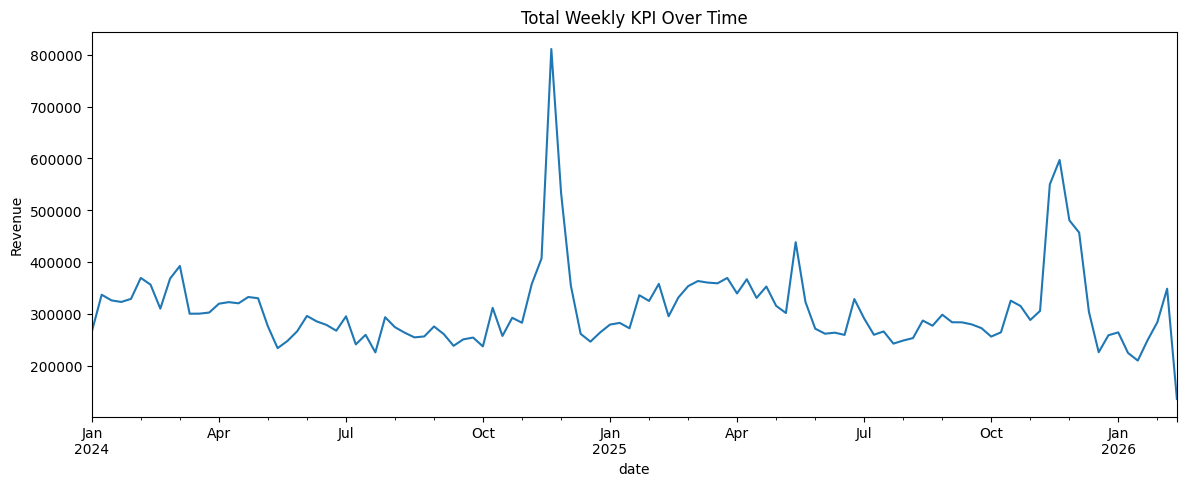

In [ ]:
plt.figure(figsize=(14,5))
raw_data.groupby('date')[kpi_col].sum().plot()
plt.title("Total Weekly KPI Over Time")
plt.ylabel(kpi_col)
plt.show()


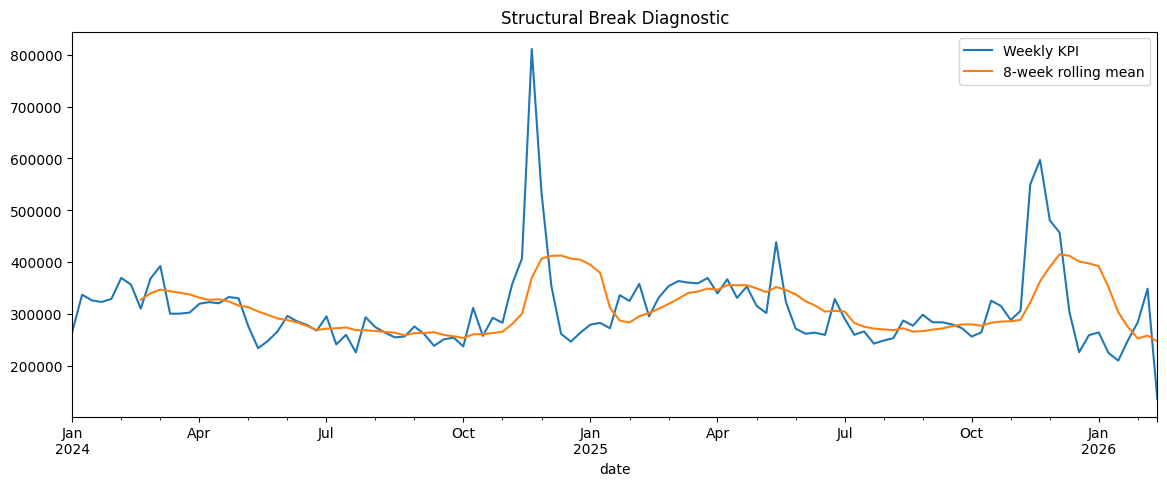

In [ ]:
weekly_total = raw_data.groupby('date')[kpi_col].sum().sort_index()

rolling_mean = weekly_total.rolling(8).mean()

plt.figure(figsize=(14,5))
weekly_total.plot(label='Weekly KPI')
rolling_mean.plot(label='8-week rolling mean')
plt.legend()
plt.title("Structural Break Diagnostic")
plt.show()

In [ ]:
for geo in raw_data['geo'].unique():
    geo_df = raw_data[raw_data['geo'] == geo]
    weekly = geo_df.groupby('date')[kpi_col].sum()

    plt.figure(figsize=(10,3))
    weekly.plot()
    plt.title(f"{geo} - Weekly {kpi_col}")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

#### Validate units/spend relationship (CPM/CPC/CPA stability assumptions)

- Assuming these are okay given they are heavily monitered by account managers
- Just looking to make sure efficiency metrics are relatively stable over time

#### Document data caveats and “known unknowns” for priors/spec choices

- Amazon Data is Geo allocated not actauls
- Major spikes around Black Friday
- Can drop Performance Max (no data), Competitors (very little data), combine brand shopping, and possibly remarketing

### 3) Control-variable selection and time effects plan


####
- Build/confirm a causal story (DAG mindset) for confounding controls
- Include all important confounders that affect both media execution and KPI
- Avoid including controls that are not confounders (reduce misspecification risk)


- Demand ────────────┐          
- Media Spend ───────→ KPI (Revenue)
- Black Friday  ──────────┘
- (Promos, GQV Data)

### Decide how to represent time:

- Knots (trend/seasonality spline baseline)
- Binary indicators (geo-dependent time effects where appropriate)
- Periodic functions (esp. for national models / parsimony)


In [ ]:
# Simple V1 Model use less knots (about 1 per month)
knots = 24

Auto Knot Selection:

In [ ]:
# model_spec = spec.ModelSpec(enable_aks=True)

# mmm = model.Meridian(model_spec=model_spec)
# # ... build data + fit model as usual

# knot_info = mmm.knot_info
# selected_knots = knot_info.knot_locations
# selected_knots

In [ ]:
# Inspect Knot Location
# mmm.knot_info.knot_locations
# np.diff(mmm.knot_info.knot_locations)

### 4) Model specification design (core MMM structure)

#### Set max_lag (how long media impact lasts)

In [ ]:
channels = ['Brand', 'Non_Brand', 'DVD', 'Retargeting', 'Prospecting', 'Remarketing', 'Amazon', 'Shopping']
spend_cols = [f'{c}_Cost' for c in channels]

weekly = raw_data.groupby('date')[spend_cols + ['Revenue']].sum().sort_index()
weekly.head()

,Brand_Cost,Non_Brand_Cost,DVD_Cost,Retargeting_Cost,Prospecting_Cost,Remarketing_Cost,Amazon_Cost,Shopping_Cost,Revenue
date,,,,,,,,,
2024-01-01,2351.86,18897.19,946.745403,3095.850160,11514.760642,0.0,0.0,5401.60,266297.30
2024-01-08,2341.34,15650.92,768.088336,3009.820158,11382.560995,0.0,0.0,8551.84,336920.88
2024-01-15,2262.08,13659.06,2057.202293,3332.000254,11921.100823,0.0,0.0,6557.64,325968.21
2024-01-22,2148.99,15024.71,2561.264237,3525.015424,11968.473100,0.0,0.0,6893.40,322917.68
2024-01-29,2361.83,11115.89,1877.146140,3522.820079,11969.800367,0.0,0.0,13786.26,328857.02


In [ ]:
max_lag_to_test = 8  # explore beyond what you might pick
lag_corrs = []

for col in spend_cols:
    for lag in range(0, max_lag_to_test + 1):
        corr = weekly[col].corr(weekly['Revenue'].shift(-lag))
        lag_corrs.append({'channel': col, 'lag_weeks': lag, 'corr': corr})

lag_corrs = pd.DataFrame(lag_corrs)
lag_corrs.sort_values(['channel', 'lag_weeks'])

,channel,lag_weeks,corr
54,Amazon_Cost,0,0.559378
55,Amazon_Cost,1,0.402826
56,Amazon_Cost,2,0.232140
57,Amazon_Cost,3,0.090523
58,Amazon_Cost,4,-0.021874
...,...,...,...
67,Shopping_Cost,4,0.001668
68,Shopping_Cost,5,-0.020605
69,Shopping_Cost,6,-0.073185
70,Shopping_Cost,7,-0.094462


In [ ]:
threshold = 0.10  # heuristic; adjust based on your noise level

tail = (lag_corrs[lag_corrs['corr'] > threshold]
        .groupby('channel')['lag_weeks']
        .max()
        .reset_index()
        .rename(columns={'lag_weeks':'max_lag_suggested'}))

tail

,channel,max_lag_suggested
0,Amazon_Cost,2
1,Brand_Cost,2
2,DVD_Cost,8
3,Non_Brand_Cost,2
4,Prospecting_Cost,2
5,Remarketing_Cost,3
6,Retargeting_Cost,1
7,Shopping_Cost,2


In [ ]:
# Test a few options
#max_lag = 6
#max_lag = 8
max_lag = 4

#### Choose adstock_decay_spec (decay shape)

Start with Geometrics (rule of thumb: use binomial when you believe a meaningful share of impact persists into the latter half of your max_lag window; otherwise use geometric.)

In [ ]:
# model_spec = spec.ModelSpec(
#     max_lag=6,
#     adstock_decay_spec='geometric',   # <- start here
#     knots=24,
# )

# model_spec = spec.ModelSpec(
#     max_lag=6,
#     adstock_decay_spec={
#         'Brand': 'geometric',
#         'Non_Brand': 'geometric',
#         'Retargeting': 'geometric',
#         'Prospecting': 'geometric',   # consider binomial later
#         'DVD': 'geometric',           # consider binomial later for YouTube if justified
#     },
#     knots=24,
# )

- If you want, next we can do the next step in your checklist: set priors on the decay parameter 𝛼
- α (e.g., encouraging faster vs slower decay), because that’s the other half of making the lag behavior realistic.

In [ ]:
# prior = priors.PriorDistribution(
#     # other priors...

#     # Conceptually: alpha prior per channel
#     # Fast-decay channels:
#     adstock_alpha={
#         "Brand": priors.Beta(2.0, 8.0),        # centered lower
#         "Non_Brand": priors.Beta(2.0, 8.0),
#         "Retargeting": priors.Beta(2.0, 8.0),

#         # Slower-decay channels:
#         "Prospecting": priors.Beta(5.0, 2.0),  # centered higher
#         "DVD": priors.Beta(5.0, 2.0),
#     }
# )

### Set saturation values

Leave as defualt for V1, tune when you get richer data: GQV, promo if needed

### 5) Priors strategy (default → custom → calibrated)


####Treatment Prior Types will be ROI

In [ ]:
# ---- Inputs from your geo holdout test (example placeholders) ----
# prospecting_roi_mean = 1.50          # e.g., point estimate of ROI (Revenue / Spend)
# prospecting_roi_se   = 0.30          # e.g., standard error of the ROI estimate (or choose a subjective std)

# # If you prefer a range instead of mean+se:
# # low, high = 0.6, 2.0
# # roi_dist = prior_distribution.lognormal_dist_from_range(low=low, high=high, mass_percent=0.95)

# roi_dist = prior_distribution.lognormal_dist_from_mean_std(
#     mean=prospecting_roi_mean,
#     std=prospecting_roi_se
# )

In [ ]:
# from meridian.model import prior_distribution as priors

# channels = ['Brand', 'Non_Brand', 'DVD', 'Retargeting', 'Prospecting']

# # Start with "None" (meaning: let defaults apply), then override Prospecting.
# # If your Meridian version requires explicit dists for all channels, we’ll create defaults for the rest.
# roi_m = [None] * len(channels)
# roi_m[channels.index('Prospecting')] = roi_dist

# prior = priors.PriorDistribution(
#     roi_m=roi_m
# )

In [ ]:
# model_spec = spec.ModelSpec(
#     media_prior_type="roi",
#     prior=prior,
    # Restrict ROI calibration to a time window that matches the experiment (if desired)
    # roi_calibration_period=("2025-09-10", "2025-10-08"),  # example (start, end)
# )

### Add Promo Data to dataset

In [44]:
promo_data = pd.read_csv("NS_Promos_Apr_26.csv")

In [45]:
promo_data['Promo Intensity'] = promo_data['Promo Intensity'].str.replace('%', '').astype(float) / 100

In [ ]:
promo_data.head(50)

,Date,Promo Intensity,Product Launch
0,2024-01-01,0.20,NaN
1,2024-01-08,0.20,NaN
2,2024-01-15,0.20,NaN
3,2024-01-22,0.20,NaN
4,2024-01-29,0.20,NaN
5,2024-02-05,0.20,NaN
6,2024-02-12,0.40,NaN
7,2024-02-19,0.20,NaN
8,2024-02-26,0.20,NaN
9,2024-03-04,0.20,NaN


In [46]:
promo_data['Date'] = pd.to_datetime(promo_data['Date'])

raw_data = pd.merge(
    raw_data,
    promo_data,
    left_on='date',
    right_on='Date',
    how='left'
).drop(columns=['Date'])

# Fill NaN values in the newly merged columns from promo_data with 0
raw_data['Promo Intensity'] = raw_data['Promo Intensity'].fillna('0%') # Fill with a string to match existing data type if any
raw_data['Product Launch'] = raw_data['Product Launch'].fillna(0) # Fill with 0 as it seems to be an indicator


In [47]:
raw_data

,date,geo,DVD_Cost,Retargeting_Cost,Shopping_Cost,Prospecting_Cost,Remarketing_Cost,Brand_Cost,Non_Brand_Cost,DVD_Impressions,...,population,Pmax_Cost,Pmax_Impressions,Facebook_Views,Instagram_Views,YouTube_Views,weekly_average_temp,weekly_rainfall,Promo Intensity,Product Launch
0,2024-01-01,AK,7.022993,17.694355,14.75,65.032256,0.000000,5.400000,88.710000,282,...,750000,0.000000,0.0,0.000000,0.000000,0.000000,17.431020,0.379921,0.2,0.0
1,2024-01-08,AK,3.164727,16.395904,44.81,60.292926,0.000000,5.510000,66.600000,209,...,750000,0.000000,0.0,0.000000,0.000000,0.000000,16.020408,0.330217,0.2,0.0
2,2024-01-15,AK,9.586830,16.064609,23.62,68.541314,0.000000,16.710000,75.610000,790,...,750000,0.000000,0.0,0.000000,0.000000,0.000000,9.716735,0.632382,0.2,0.0
3,2024-01-22,AK,10.641802,19.754004,21.61,74.123413,0.000000,13.370000,88.900000,761,...,750000,0.000000,0.0,0.000000,0.000000,0.000000,-10.149388,0.514483,0.2,0.0
4,2024-01-29,AK,9.629326,20.485583,65.43,70.342600,0.000000,40.190000,50.310000,436,...,750000,0.000000,0.0,0.000000,0.000000,0.000000,-3.921633,0.875141,0.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6268,2026-04-06,WY,2.007097,2.490032,34.06,48.755216,2.120087,5.614402,15.410102,196,...,590000,7.959174,1187.129295,103.770468,13.045020,208.532302,46.885714,0.000000,0.2,0.0
6269,2026-04-13,WY,5.055754,2.840230,35.58,71.064208,2.990076,5.091891,17.134397,360,...,590000,8.369750,1257.159105,107.679530,20.078597,61.485254,46.085714,0.060000,0.2,0.0
6270,2026-04-20,WY,5.103239,1.929980,33.48,54.127366,1.879959,17.179857,33.457941,490,...,590000,11.198540,1367.346109,40.172577,18.159105,111.863781,50.000000,0.020000,0.2,0.0
6271,2026-04-27,WY,2.082808,2.330109,17.13,32.799533,0.889935,3.892109,39.000894,191,...,590000,8.903954,997.933774,228.971551,6.166985,93.807231,41.700000,0.240000,0.2,0.0


### Add in Temp Data

In [36]:
weekly_temp = pd.read_csv("weekly_temp_data_Apr26.csv")

In [37]:
weekly_temp

,Unnamed: 0,state,week_start,weekly_average_temp,weekly_rainfall
0,0,AK,2024-01-01,17.431020,0.379921
1,1,AK,2024-01-08,16.020408,0.330217
2,2,AK,2024-01-15,9.716735,0.632382
3,3,AK,2024-01-22,-10.149388,0.514483
4,4,AK,2024-01-29,-3.921633,0.875141
...,...,...,...,...,...
6145,6145,WY,2026-04-06,46.885714,0.000000
6146,6146,WY,2026-04-13,46.085714,0.060000
6147,6147,WY,2026-04-20,50.000000,0.020000
6148,6148,WY,2026-04-27,41.700000,0.240000


In [38]:
weekly_temp.rename(columns={'state': 'geo', 'week_start': 'date'}, inplace=True)

In [39]:
# 1. Ensure date columns are datetime objects
weekly_temp['date'] = pd.to_datetime(weekly_temp['date'], format='mixed')
raw_data['date'] = pd.to_datetime(raw_data['date'])

# 2. The weekly_temp DataFrame already has 'geo' and 'date' columns correctly named.
#    The rename step for 'state' and 'week_start' is unnecessary and has been removed.

# 3. Merge weekly_temp into raw_data using a left join on 'date' and 'geo'
raw_data = pd.merge(
    raw_data,
    weekly_temp[['date', 'geo', 'weekly_average_temp', 'weekly_rainfall']],
    on=['date', 'geo'],
    how='left'
)

# 4. Fill NaN values in the newly merged columns from weekly_temp with 0
raw_data['weekly_average_temp'] = raw_data['weekly_average_temp'].fillna(0)
raw_data['weekly_rainfall'] = raw_data['weekly_rainfall'].fillna(0)

print("Weekly temperature and rainfall data merged successfully!")

Weekly temperature and rainfall data merged successfully!


In [40]:
raw_data.head(20)

,date,geo,DVD_Cost,Competitors_Cost,Retargeting_Cost,Brand_Shopping_Cost,Shopping_Cost,Prospecting_Cost,Remarketing_Cost,Brand_Cost,...,Revenue,bf_date,population,Pmax_Cost,Pmax_Impressions,Facebook_Views,Instagram_Views,YouTube_Views,weekly_average_temp,weekly_rainfall
0,2024-01-01,AK,7.022993,0.0,17.694355,0.0,14.75,65.032256,0.0,5.40,...,1358.99,0,750000,0.0,0.0,0.000000,0.0,0.000000,17.431020,0.379921
1,2024-01-08,AK,3.164727,0.0,16.395904,0.0,44.81,60.292926,0.0,5.51,...,1745.00,0,750000,0.0,0.0,0.000000,0.0,0.000000,16.020408,0.330217
2,2024-01-15,AK,9.586830,0.0,16.064609,0.0,23.62,68.541314,0.0,16.71,...,1995.00,0,750000,0.0,0.0,0.000000,0.0,0.000000,9.716735,0.632382
3,2024-01-22,AK,10.641802,0.0,19.754004,0.0,21.61,74.123413,0.0,13.37,...,2437.00,0,750000,0.0,0.0,0.000000,0.0,0.000000,-10.149388,0.514483
4,2024-01-29,AK,9.629326,0.0,20.485583,0.0,65.43,70.342600,0.0,40.19,...,1920.00,0,750000,0.0,0.0,0.000000,0.0,0.000000,-3.921633,0.875141
5,2024-02-05,AK,17.149615,0.0,23.833707,0.0,80.74,65.593529,0.0,20.94,...,971.00,0,750000,0.0,0.0,0.000000,0.0,0.000000,17.993061,0.253656
6,2024-02-12,AK,15.765975,0.0,27.152024,0.0,74.79,58.865473,0.0,8.99,...,2476.40,0,750000,0.0,0.0,0.000000,0.0,38.562489,22.717143,0.421893
7,2024-02-19,AK,10.391942,0.0,27.259346,0.0,109.67,63.841547,0.0,10.12,...,1119.00,0,750000,0.0,0.0,0.000000,0.0,29.199983,16.854286,0.551462
8,2024-02-26,AK,10.890744,0.0,22.143071,0.0,191.86,56.917678,0.0,13.31,...,1218.99,0,750000,0.0,0.0,0.000000,0.0,28.213541,0.635918,0.221597
9,2024-03-04,AK,8.223371,0.0,20.937694,0.0,70.00,68.044434,0.0,19.12,...,1594.50,0,750000,0.0,0.0,0.000000,0.0,31.142447,7.009388,0.415846


### Prep Data to send to modeling notebook

In [41]:
raw_data["Brand_Cost"] = raw_data["Brand_Cost"] + raw_data["Brand_Shopping_Cost"]
raw_data["Brand_Impressions"] = raw_data["Brand_Impressions"] + raw_data["Brand_Shopping_Impressions"]
# raw_data["Shopping_Cost"] = raw_data["Shopping_Cost"] + raw_data["Performance_Max_Cost"]
# raw_data["Shopping_Impressions"] = raw_data["Shopping_Impressions"] + raw_data["Performance_Max_Impressions"]
raw_data["Non_Brand_Cost"] = raw_data["Non_Brand_Cost"] + raw_data["Competitors_Cost"]
raw_data["Non_Brand_Impressions"] = raw_data["Non_Brand_Impressions"] + raw_data["Competitors_Impressions"]

In [42]:
raw_data.drop(columns=["Competitors_Cost", "Competitors_Impressions", "Brand_Shopping_Cost", "Brand_Shopping_Impressions"], inplace=True)

### To csv

In [48]:
raw_data.to_csv("NS_mmm_data_Apr26.csv", index=False)

#### Create Indoor vs Outdoor Datasets

In [ ]:
# Indoor

# BoomRoom
# Monotub
# Cultures
# Fruiting Blocks
# Noc Box
# Parts & Supplies
# Spray & Grow
# Substrates
# ShroomTek


# Outdoor

# Outdoor Spawn
# Mycosphere
# Bucket
# Plant and Grow Blocks


# N/A

# Wellness
# Other

Indoor

In [ ]:
raw_data

#### Temp to Sales Corr

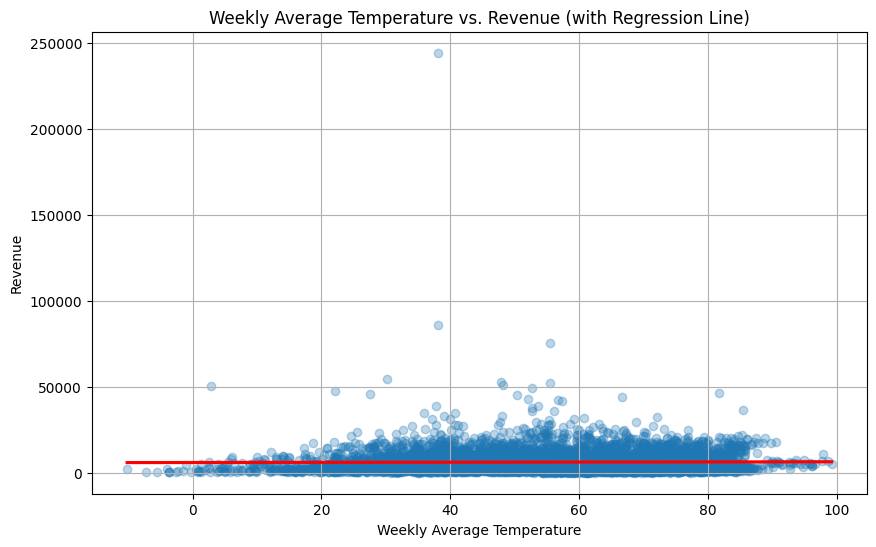

Pearson correlation between Weekly Average Temperature and Revenue: 0.01


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# remove rows where raw_data weekly_average_temp = 0
raw_data = raw_data[raw_data['weekly_average_temp'] != 0]

# Create the scatterplot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=raw_data, x='weekly_average_temp', y='Revenue', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Weekly Average Temperature vs. Revenue (with Regression Line)')
plt.xlabel('Weekly Average Temperature')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# Calculate the correlation score
correlation = raw_data['weekly_average_temp'].corr(raw_data['Revenue'])
print(f"Pearson correlation between Weekly Average Temperature and Revenue: {correlation:.2f}")
